# Station-Specific Training Experiment

**Hypothesis:** Error analysis revealed station 3 has 55% accuracy vs station 1's 35%. Is this due to:
- (A) Different annotation quality across stations, or
- (B) Different visual characteristics (camera, lighting, clothing mix)?

**Experiment:** Train the V2 model on station 3 data only, evaluate on station 1. Then vice versa. If a station-specific model performs much better on its own station but poorly on others, it confirms the stations are genuinely different domains.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Device: {DEVICE}")

df = pd.read_csv(Path("../data/cleaned_metadata_v2.csv"))

# Station breakdown
print("\nFull dataset by station:")
for station, group in df.groupby("station"):
    train_n = len(group[group["split"] == "train"])
    test_n  = len(group[group["split"] == "test"])
    print(f"  {station}: {len(group):,} total  (train={train_n:,}, test={test_n:,})")
    print(f"    condition dist: {dict(group['condition'].value_counts().sort_index())}")

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps

Full dataset by station:
  station1: 21,839 total  (train=17,542, test=4,297)
    condition dist: {1: np.int64(895), 2: np.int64(4477), 3: np.int64(7244), 4: np.int64(3392), 5: np.int64(5831)}
  station2: 2,681 total  (train=2,155, test=526)
    condition dist: {1: np.int64(151), 2: np.int64(350), 3: np.int64(1233), 4: np.int64(534), 5: np.int64(413)}
  station3: 7,416 total  (train=5,851, test=1,565)
    condition dist: {1: np.int64(37), 2: np.int64(238), 3: np.int64(1274), 4: np.int64(3876), 5: np.int64(1991)}


In [2]:
# ── Shared infrastructure ─────────────────────────────────────────────────────

IMG_SIZE = 260
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=20, scale=(0.85, 1.15), shear=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ClothingDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        front = Image.open(row["front_path"]).convert("RGB")
        back  = Image.open(row["back_path"]).convert("RGB")
        if self.transform:
            front = self.transform(front)
            back  = self.transform(back)
        labels = {"condition": torch.tensor(row["condition"] - 1, dtype=torch.long)}
        return front, back, labels


def ordinal_soft_labels(targets, num_classes=5, sigma=1.0):
    classes = torch.arange(num_classes, device=targets.device).float()
    targets_f = targets.float().unsqueeze(1)
    soft = torch.exp(-0.5 * ((classes - targets_f) / sigma) ** 2)
    return soft / soft.sum(dim=1, keepdim=True)

def ordinal_kl_loss(logits, targets, num_classes=5, sigma=1.0):
    soft_targets = ordinal_soft_labels(targets, num_classes, sigma)
    log_probs = F.log_softmax(logits, dim=1)
    return F.kl_div(log_probs, soft_targets, reduction='batchmean')


class SimpleConditionModel(nn.Module):
    """Simplified dual-stream model — condition head only (faster training)."""
    def __init__(self, backbone_name="efficientnet_b2", pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            in_chans=3, num_classes=0, global_pool="avg")
        cd = self.backbone.num_features * 2
        self.head = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(cd, 256), nn.ReLU(inplace=True),
            nn.Dropout(0.3), nn.Linear(256, 5))
    def forward(self, front, back):
        return self.head(torch.cat([self.backbone(front), self.backbone(back)], dim=1))

print("Infrastructure ready.")

Infrastructure ready.


In [3]:
USE_AMP = DEVICE.type in ("cuda", "mps")
amp_dtype = torch.float16

def train_and_evaluate(train_df, test_df, label, num_epochs=10, patience=3):
    """Train a fresh model on train_df, evaluate on test_df. Returns metrics dict."""
    print(f"\n{'='*60}")
    print(f"  Experiment: {label}")
    print(f"  Train: {len(train_df):,}  Test: {len(test_df):,}")
    print(f"{'='*60}")
    
    train_loader = DataLoader(ClothingDataset(train_df, train_transforms),
                              batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader  = DataLoader(ClothingDataset(test_df, test_transforms),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    model = SimpleConditionModel(pretrained=True).to(DEVICE)
    
    # Freeze backbone initially
    for p in model.backbone.parameters():
        p.requires_grad = False
    
    head_params = [p for n, p in model.named_parameters() if "backbone" not in n]
    optimizer = torch.optim.AdamW(head_params, lr=1e-3, weight_decay=1e-4)
    spe = len(train_loader)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=1e-3, epochs=num_epochs, steps_per_epoch=spe,
        pct_start=0.1, anneal_strategy="cos")
    
    unfreeze_at = 3
    best_val_loss = float("inf")
    patience_ctr = 0
    
    for epoch in range(1, num_epochs + 1):
        if epoch == unfreeze_at:
            for p in model.backbone.parameters():
                p.requires_grad = True
            optimizer.add_param_group({"params": list(model.backbone.parameters()),
                                       "lr": 1e-4, "weight_decay": 1e-4})
            remaining = num_epochs - epoch + 1
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=[5e-4, 1e-4],
                epochs=remaining, steps_per_epoch=spe,
                pct_start=0.05, anneal_strategy="cos")
            print(f"  ★ Backbone unfrozen at epoch {epoch}")
        
        # Train
        model.train()
        for fronts, backs, labels in tqdm(train_loader, desc=f"  e{epoch} train", leave=False):
            fronts = fronts.to(DEVICE); backs = backs.to(DEVICE)
            targets = labels["condition"].to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=USE_AMP):
                logits = model(fronts, backs)
                loss = ordinal_kl_loss(logits, targets)
            optimizer.zero_grad(); loss.backward(); optimizer.step(); scheduler.step()
            if DEVICE.type == "mps": torch.mps.synchronize()
        
        # Eval
        model.eval()
        all_p, all_t = [], []
        val_loss_sum, val_n = 0.0, 0
        with torch.no_grad():
            for fronts, backs, labels in test_loader:
                fronts = fronts.to(DEVICE); backs = backs.to(DEVICE)
                targets = labels["condition"].to(DEVICE)
                with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=USE_AMP):
                    logits = model(fronts, backs)
                    loss = ordinal_kl_loss(logits, targets)
                val_loss_sum += loss.item() * fronts.size(0)
                val_n += fronts.size(0)
                all_p.append(logits.argmax(1).cpu())
                all_t.append(labels["condition"])
        
        all_p = torch.cat(all_p).numpy()
        all_t = torch.cat(all_t).numpy()
        val_loss = val_loss_sum / val_n
        acc = (all_p == all_t).mean()
        mae_val = np.abs(all_p - all_t).mean()
        one_off = (np.abs(all_p - all_t) <= 1).mean()
        
        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            patience_ctr = 0
            best_metrics = {"acc": acc, "mae": mae_val, "one_off": one_off,
                           "preds": all_p, "targets": all_t, "epoch": epoch}
        else:
            patience_ctr += 1
        
        mark = "✓" if improved else f"✗ ({patience_ctr}/{patience})"
        print(f"  e{epoch}  acc={acc:.4f}  MAE={mae_val:.3f}  1-off={one_off:.4f}  {mark}")
        
        if patience_ctr >= patience:
            print(f"  Early stopped at epoch {epoch}")
            break
    
    print(f"  Best: acc={best_metrics['acc']:.4f}  MAE={best_metrics['mae']:.3f}  "
          f"1-off={best_metrics['one_off']:.4f} (epoch {best_metrics['epoch']})")
    
    del model
    if DEVICE.type == "mps": torch.mps.empty_cache()
    
    return best_metrics

print("train_and_evaluate() defined.")

train_and_evaluate() defined.


## Run Experiments

Three experiments:
1. **Train station 3 → Test station 3** (in-domain baseline for station 3)
2. **Train station 3 → Test station 1** (cross-domain: does station 3 knowledge transfer?)
3. **Train station 1 → Test station 1** (in-domain baseline for station 1)

Use 80/20 splits within each station for in-domain experiments.

In [4]:
from sklearn.model_selection import train_test_split

s1 = df[df["station"] == "station1"]
s3 = df[df["station"] == "station3"]

# 80/20 splits within each station
s1_train, s1_test = train_test_split(s1, test_size=0.2, random_state=42, stratify=s1["condition"])
s3_train, s3_test = train_test_split(s3, test_size=0.2, random_state=42, stratify=s3["condition"])

print(f"Station 1: train={len(s1_train):,}  test={len(s1_test):,}")
print(f"Station 3: train={len(s3_train):,}  test={len(s3_test):,}")

Station 1: train=17,471  test=4,368
Station 3: train=5,932  test=1,484


In [5]:
# Experiment 1: Train on station 3, test on station 3 (in-domain)
exp1 = train_and_evaluate(s3_train, s3_test, "Station 3 → Station 3 (in-domain)")


  Experiment: Station 3 → Station 3 (in-domain)
  Train: 5,932  Test: 1,484


  e1  acc=0.4987  MAE=0.551  1-off=0.9562  ✓


  e2  acc=0.5229  MAE=0.520  1-off=0.9616  ✓
  ★ Backbone unfrozen at epoch 3


  e3  acc=0.5249  MAE=0.519  1-off=0.9609  ✗ (1/3)


  e4  acc=0.5182  MAE=0.534  1-off=0.9535  ✓


...

  e6  acc=0.5438  MAE=0.508  1-off=0.9522  ✗ (1/3)


  e7  acc=0.5357  MAE=0.511  1-off=0.9575  ✓


  e8  acc=0.5155  MAE=0.545  1-off=0.9447  ✗ (1/3)


  e9  acc=0.5229  MAE=0.534  1-off=0.9474  ✗ (2/3)


  e10  acc=0.5283  MAE=0.523  1-off=0.9528  ✗ (3/3)
  Early stopped at epoch 10
  Best: acc=0.5357  MAE=0.511  1-off=0.9575 (epoch 7)


In [6]:
# Experiment 2: Train on station 3, test on station 1 (cross-domain)
exp2 = train_and_evaluate(s3_train, s1_test, "Station 3 → Station 1 (cross-domain)")


  Experiment: Station 3 → Station 1 (cross-domain)
  Train: 5,932  Test: 4,368


  e1  acc=0.1552  MAE=1.133  1-off=0.7534  ✓


  e2  acc=0.1559  MAE=1.132  1-off=0.7534  ✗ (1/3)
  ★ Backbone unfrozen at epoch 3


  e3  acc=0.1557  MAE=1.135  1-off=0.7527  ✗ (2/3)


  e4  acc=0.1724  MAE=1.197  1-off=0.7072  ✗ (3/3)
  Early stopped at epoch 4
  Best: acc=0.1552  MAE=1.133  1-off=0.7534 (epoch 1)


In [7]:
# Experiment 3: Train on station 1, test on station 1 (in-domain)
exp3 = train_and_evaluate(s1_train, s1_test, "Station 1 → Station 1 (in-domain)")


  Experiment: Station 1 → Station 1 (in-domain)
  Train: 17,471  Test: 4,368


  e1  acc=0.2976  MAE=1.005  1-off=0.7253  ✓


  e2  acc=0.2921  MAE=1.014  1-off=0.7260  ✓
  ★ Backbone unfrozen at epoch 3


  e3  acc=0.2859  MAE=0.970  1-off=0.7699  ✓


  e4  acc=0.3036  MAE=1.037  1-off=0.7244  ✗ (1/3)


  e5  acc=0.3214  MAE=0.988  1-off=0.7461  ✓


  e6  acc=0.3290  MAE=1.041  1-off=0.7092  ✗ (1/3)


  e7  acc=0.3507  MAE=0.986  1-off=0.7358  ✗ (2/3)


  e8  acc=0.3420  MAE=1.025  1-off=0.7191  ✗ (3/3)
  Early stopped at epoch 8
  Best: acc=0.3214  MAE=0.988  1-off=0.7461 (epoch 5)


## Results Comparison

  STATION EXPERIMENT RESULTS
  Experiment                       Accuracy      MAE      1-off
  ----------------------------------------------------------
  S3→S3 (in-domain)                  0.5357    0.511     0.9575
  S3→S1 (cross-domain)               0.1552    1.133     0.7534
  S1→S1 (in-domain)                  0.3214    0.988     0.7461
  ----------------------------------------------------------
  V2 all-stations (reference)        0.4050    0.812     0.8239


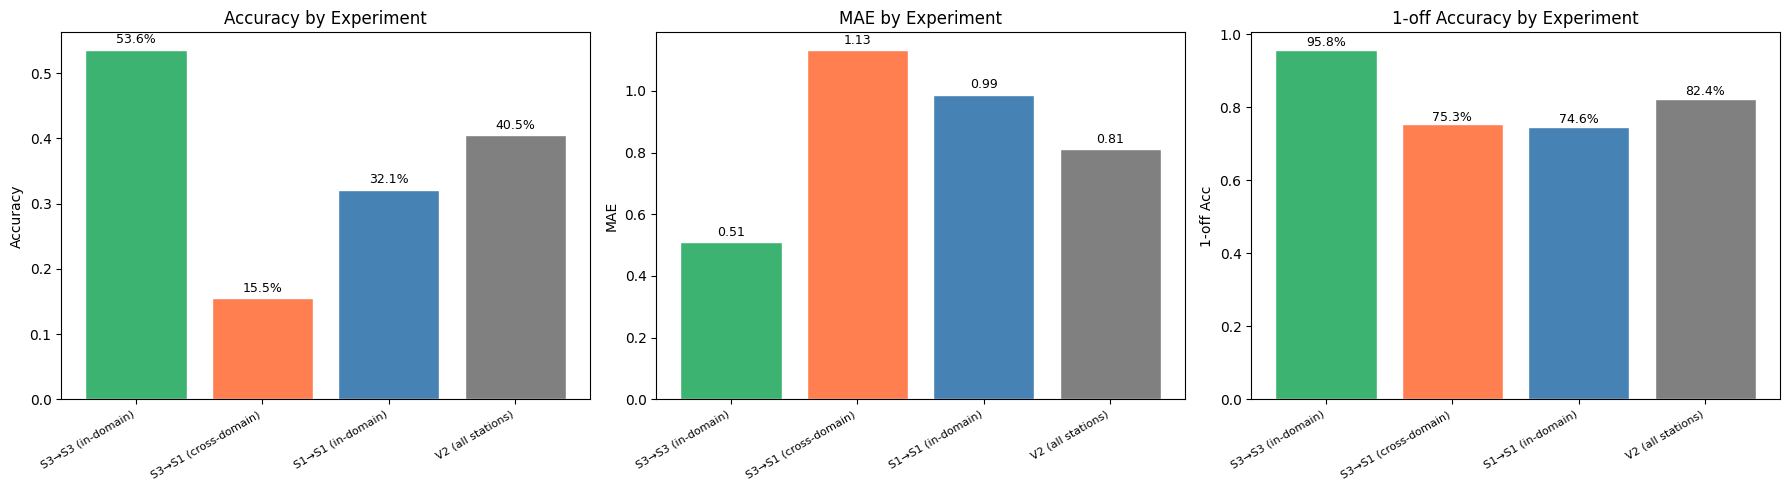

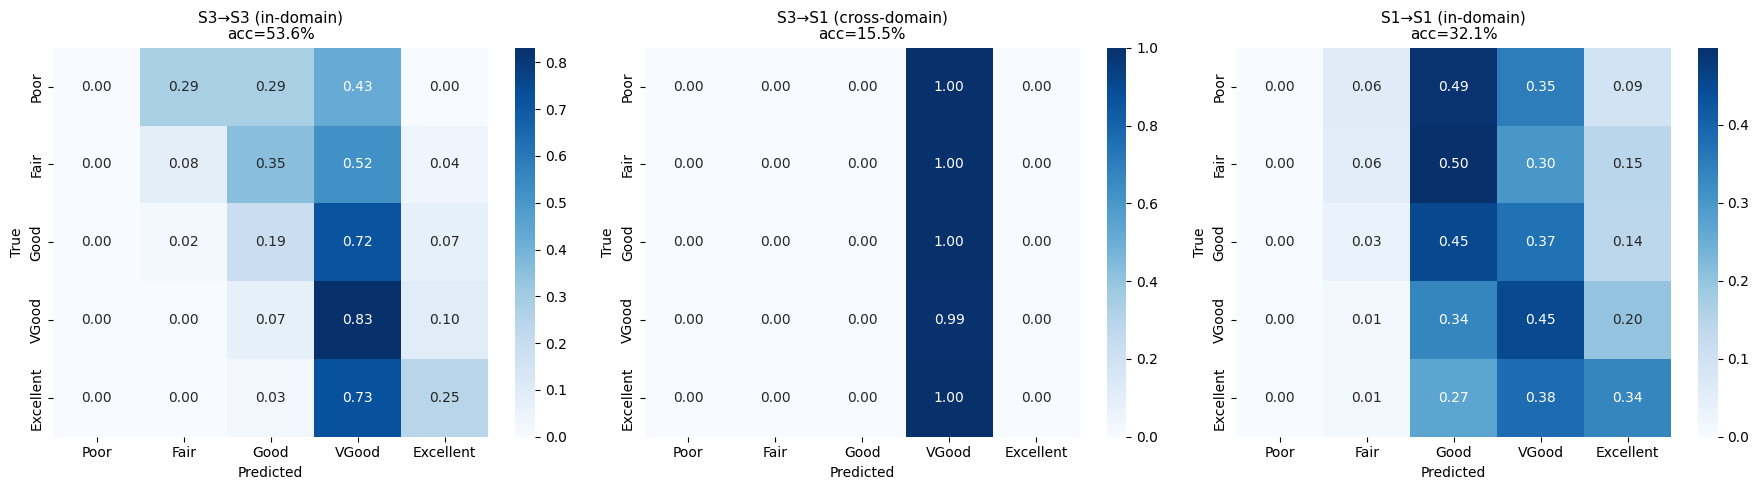

Figures saved to ../report/figures


In [8]:
FIGURES_DIR = Path("../report/figures")

# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "S3→S3 (in-domain)": exp1,
    "S3→S1 (cross-domain)": exp2,
    "S1→S1 (in-domain)": exp3,
}

print("=" * 70)
print("  STATION EXPERIMENT RESULTS")
print("=" * 70)
print(f"  {'Experiment':<30} {'Accuracy':>10} {'MAE':>8} {'1-off':>10}")
print(f"  {'-'*58}")
for name, r in results.items():
    print(f"  {name:<30} {r['acc']:>10.4f} {r['mae']:>8.3f} {r['one_off']:>10.4f}")
print(f"  {'-'*58}")
print(f"  {'V2 all-stations (reference)':<30} {'0.4050':>10} {'0.812':>8} {'0.8239':>10}")
print("=" * 70)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart comparison
names = list(results.keys()) + ["V2 (all stations)"]
accs  = [r["acc"] for r in results.values()] + [0.4050]
maes  = [r["mae"] for r in results.values()] + [0.812]
one_offs = [r["one_off"] for r in results.values()] + [0.8239]
colors = ["mediumseagreen", "coral", "steelblue", "grey"]

axes[0].bar(range(len(names)), accs, color=colors, edgecolor="white")
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=30, ha="right", fontsize=8)
axes[0].set_title("Accuracy by Experiment"); axes[0].set_ylabel("Accuracy")
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)

axes[1].bar(range(len(names)), maes, color=colors, edgecolor="white")
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=30, ha="right", fontsize=8)
axes[1].set_title("MAE by Experiment"); axes[1].set_ylabel("MAE")
for i, v in enumerate(maes):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

axes[2].bar(range(len(names)), one_offs, color=colors, edgecolor="white")
axes[2].set_xticks(range(len(names)))
axes[2].set_xticklabels(names, rotation=30, ha="right", fontsize=8)
axes[2].set_title("1-off Accuracy by Experiment"); axes[2].set_ylabel("1-off Acc")
for i, v in enumerate(one_offs):
    axes[2].text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "station_experiment.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Confusion matrices side by side ──────────────────────────────────────────
from sklearn.metrics import confusion_matrix
cond_labels = ["Poor", "Fair", "Good", "VGood", "Excellent"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["targets"], r["preds"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=cond_labels, yticklabels=cond_labels, ax=ax)
    ax.set_title(f"{name}\nacc={r['acc']:.1%}", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "station_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figures saved to {FIGURES_DIR}")